In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Load dataset (no download needed!)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("✅ Dataset loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()  # Shows first 5 rows

✅ Dataset loaded!
Rows: 891, Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# See all column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
# How many people survived vs died?
print("=== Survival Count ===")
print(df['Survived'].value_counts())
print("\n0 = Did NOT survive,  1 = Survived")

print("\n=== Basic Stats ===")
df.describe()

=== Survival Count ===
Survived
0    549
1    342
Name: count, dtype: int64

0 = Did NOT survive,  1 = Survived

=== Basic Stats ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


/tmp/ipykernel_11710/2519584732.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


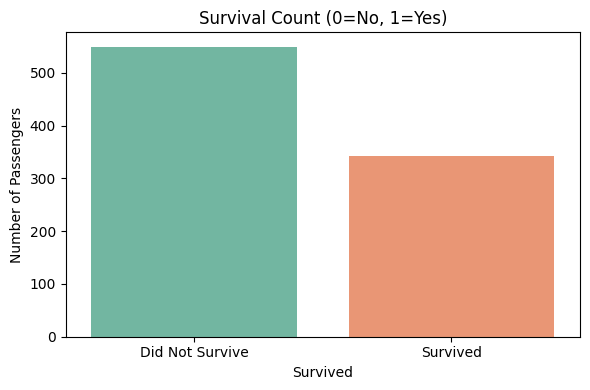

Survival Rate: 38.4%


In [7]:
# Chart 1: How many survived?
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count (0=No, 1=Yes)')
plt.xticks([0,1], ['Did Not Survive', 'Survived'])
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.show()
print(f"Survival Rate: {df['Survived'].mean()*100:.1f}%")

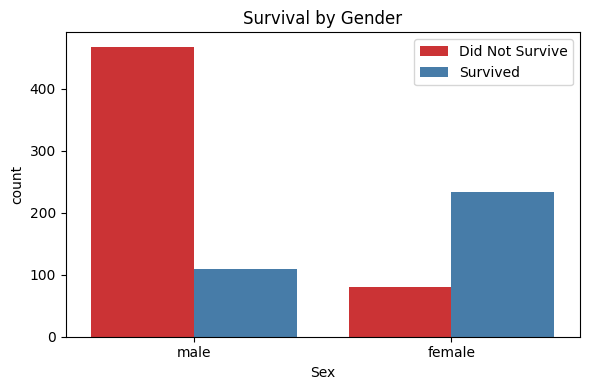

Survival rate by gender:
Sex
female    74.2%
male      18.9%
Name: Survived, dtype: object


In [8]:
# Chart 2: Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title('Survival by Gender')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()

# Print survival rates
print("Survival rate by gender:")
print(df.groupby('Sex')['Survived'].mean().apply(lambda x: f"{x*100:.1f}%"))

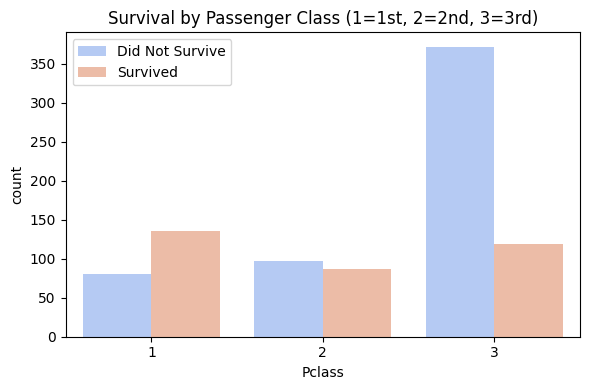

Survival rate by class:
Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: object


In [9]:
# Chart 3: Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='coolwarm')
plt.title('Survival by Passenger Class (1=1st, 2=2nd, 3=3rd)')
plt.legend(['Did Not Survive', 'Survived'])
plt.tight_layout()
plt.show()

print("Survival rate by class:")
print(df.groupby('Pclass')['Survived'].mean().apply(lambda x: f"{x*100:.1f}%"))

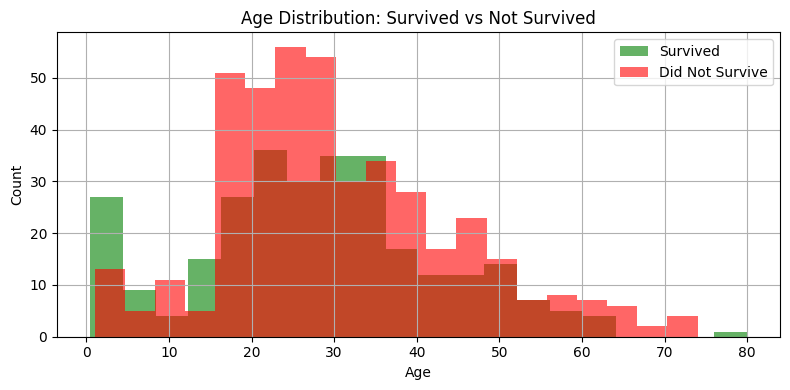

In [10]:
# Chart 4: Age distribution of survivors vs non-survivors
plt.figure(figsize=(8,4))
df[df['Survived']==1]['Age'].dropna().hist(alpha=0.6, color='green', bins=20, label='Survived')
df[df['Survived']==0]['Age'].dropna().hist(alpha=0.6, color='red',   bins=20, label='Did Not Survive')
plt.title('Age Distribution: Survived vs Not Survived')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

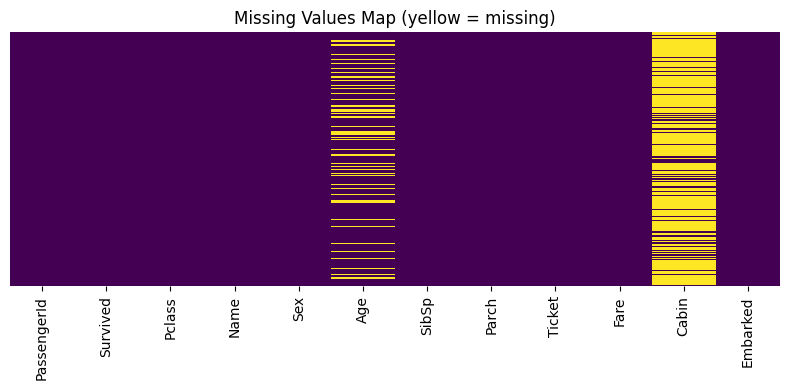


Missing value count:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [11]:
# Chart 5: Visualize where missing data exists
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Map (yellow = missing)')
plt.tight_layout()
plt.show()

# Summary of missing values
print("\nMissing value count:")
print(df.isnull().sum()[df.isnull().sum() > 0])

In [14]:
# Always work on a copy, never the original!
df_clean = df.copy()
print("Copy created! Shape:", df_clean.shape)

Copy created! Shape: (891, 12)


In [15]:
# Fill missing Age with the median age
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)

print(f"Median age used: {median_age}")
print(f"Missing Age values now: {df_clean['Age'].isnull().sum()}")  # Should print 0

Median age used: 28.0
Missing Age values now: 0


In [16]:
# Fill 2 missing Embarked values with most common port
most_common = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(most_common)

print(f"Most common port used: {most_common}")
print(f"Missing Embarked values now: {df_clean['Embarked'].isnull().sum()}")  # Should print 0

Most common port used: S
Missing Embarked values now: 0


In [24]:
# Drop Cabin safely (errors='ignore' prevents crash if already dropped)
df_clean = df_clean.drop(columns=['Cabin'], errors='ignore')

print("✅ Cabin column dropped!")
print("Remaining columns:", list(df_clean.columns))

✅ Cabin column dropped!
Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [21]:
# Name, Ticket, PassengerId won't help our model predict survival
df_clean = df_clean.drop(columns=['Name', 'Ticket', 'PassengerId'])

print("✅ Unnecessary columns dropped!")
print("Final columns:", list(df_clean.columns))
print("Shape:", df_clean.shape)

✅ Unnecessary columns dropped!
Final columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Shape: (891, 8)


In [22]:
# Convert Sex: male=0, female=1
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# Convert Embarked: S=0, C=1, Q=2
df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("✅ Text converted to numbers!")
print(df_clean.head())

✅ Text converted to numbers!
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0


In [23]:
print("=== FINAL CLEAN DATASET ===")
print(f"Shape: {df_clean.shape}")
print(f"\nMissing values:\n{df_clean.isnull().sum()}")
print(f"\nData types:\n{df_clean.dtypes}")
df_clean.head()

=== FINAL CLEAN DATASET ===
Shape: (891, 8)

Missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Data types:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [25]:
# A person travelling with family may have different survival chances
# SibSp = siblings/spouse,  Parch = parents/children
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1  # +1 for themselves

print("✅ FamilySize created!")
print(df_clean['FamilySize'].value_counts().sort_index())

✅ FamilySize created!
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


In [26]:
# Was the person travelling alone? (1=Yes, 0=No)
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

print("✅ IsAlone created!")
print("Alone passengers:", df_clean['IsAlone'].sum())
print("With family:", (df_clean['IsAlone'] == 0).sum())

✅ IsAlone created!
Alone passengers: 537
With family: 354


In [27]:
# Group ages into categories — children, teens, adults, seniors
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[0, 1, 2, 3, 4]   # 0=Child, 1=Teen, 2=YoungAdult, 3=Adult, 4=Senior
).astype(int)

print("✅ AgeGroup created!")
print("Age group counts:")
print(df_clean['AgeGroup'].value_counts().sort_index())

✅ AgeGroup created!
Age group counts:
AgeGroup
0     69
1     70
2    535
3    195
4     22
Name: count, dtype: int64


In [28]:
# Group fare prices into cheap/mid/expensive/luxury
df_clean['FareGroup'] = pd.qcut(
    df_clean['Fare'],
    q=4,
    labels=[0, 1, 2, 3]   # 0=Cheapest, 3=Most expensive
).astype(int)

print("✅ FareGroup created!")
print("Fare group counts:")
print(df_clean['FareGroup'].value_counts().sort_index())

✅ FareGroup created!
Fare group counts:
FareGroup
0    223
1    224
2    222
3    222
Name: count, dtype: int64


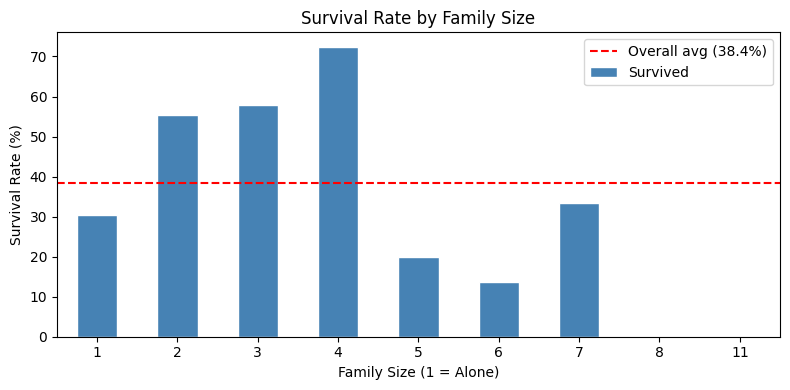

In [29]:
plt.figure(figsize=(8, 4))
survival_by_family = df_clean.groupby('FamilySize')['Survived'].mean() * 100
survival_by_family.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size (1 = Alone)')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=38.4, color='red', linestyle='--', label='Overall avg (38.4%)')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
print("=== FINAL DATASET WITH NEW FEATURES ===")
print(f"Shape: {df_clean.shape}")
print(f"\nAll columns: {list(df_clean.columns)}")
print(f"\nMissing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

=== FINAL DATASET WITH NEW FEATURES ===
Shape: (891, 12)

All columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup']

Missing values: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,AgeGroup,FareGroup
0,0,3,0,22.0,1,0,7.2500,0,2,0,2,0
1,1,1,1,38.0,1,0,71.2833,1,2,0,3,3
2,1,3,1,26.0,0,0,7.9250,0,1,1,2,1
3,1,1,1,35.0,1,0,53.1000,0,2,0,2,3
4,0,3,0,35.0,0,0,8.0500,0,1,1,2,1


In [31]:
# X = what we use to predict (all columns except Survived)
# y = what we want to predict (Survived column)

X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

print("✅ Features and Target created!")
print(f"X shape (features): {X.shape}")
print(f"y shape (target):   {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

✅ Features and Target created!
X shape (features): (891, 11)
y shape (target):   (891,)

Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup']


In [32]:
from sklearn.model_selection import train_test_split

# 80% data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Train/Test split done!")
print(f"Training samples:  {X_train.shape[0]}")
print(f"Testing samples:   {X_test.shape[0]}")

✅ Train/Test split done!
Training samples:  712
Testing samples:   179


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Test the model
lr_pred = lr_model.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f"✅ Logistic Regression Accuracy: {lr_acc*100:.2f}%")

✅ Logistic Regression Accuracy: 79.89%


In [34]:
from sklearn.ensemble import RandomForestClassifier

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Test the model
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")

✅ Random Forest Accuracy: 82.68%


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("=" * 45)
print("         MODEL COMPARISON REPORT")
print("=" * 45)
print(f"  Logistic Regression : {lr_acc*100:.2f}%")
print(f"  Random Forest       : {rf_acc*100:.2f}%")
print(f"\n  Best Model: {'Random Forest' if rf_acc > lr_acc else 'Logistic Regression'}")
print("=" * 45)

# Detailed report for best model
best_pred = rf_pred if rf_acc > lr_acc else lr_pred
print("\n📊 Detailed Classification Report (Best Model):")
print(classification_report(y_test, best_pred,
      target_names=['Did Not Survive', 'Survived']))

         MODEL COMPARISON REPORT
  Logistic Regression : 79.89%
  Random Forest       : 82.68%

  Best Model: Random Forest

📊 Detailed Classification Report (Best Model):
                 precision    recall  f1-score   support

Did Not Survive       0.84      0.87      0.85       105
       Survived       0.80      0.77      0.79        74

       accuracy                           0.83       179
      macro avg       0.82      0.82      0.82       179
   weighted avg       0.83      0.83      0.83       179



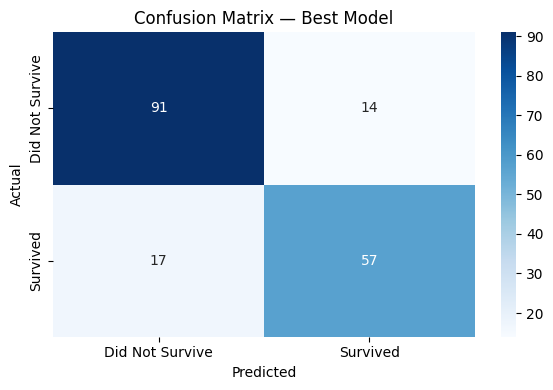


✅ Correctly predicted 'Did Not Survive': 91
✅ Correctly predicted 'Survived':         57
❌ Wrong predictions:                      31


In [36]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix — Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Explain the numbers
tn, fp, fn, tp = cm.ravel()
print(f"\n✅ Correctly predicted 'Did Not Survive': {tn}")
print(f"✅ Correctly predicted 'Survived':         {tp}")
print(f"❌ Wrong predictions:                      {fp + fn}")

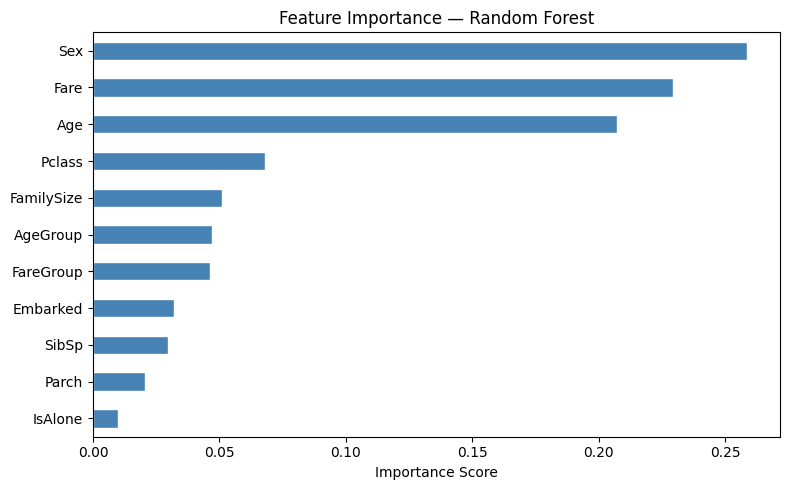


Top 3 most important features:
Sex     0.258844
Fare    0.229487
Age     0.207308
dtype: float64


In [37]:
# Which features helped the model the most?
feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
print(feat_importance.sort_values(ascending=False).head(3))

In [38]:
# Let's predict survival for a made-up passenger!
# Female, 1st class, age 28, alone, paid high fare
new_passenger = pd.DataFrame({
    'Pclass':     [1],
    'Sex':        [1],      # 1 = female
    'Age':        [28.0],
    'SibSp':      [0],
    'Parch':      [0],
    'Fare':       [72.0],
    'Embarked':   [1],      # C = Cherbourg
    'FamilySize': [1],
    'IsAlone':    [1],
    'AgeGroup':   [2],      # YoungAdult
    'FareGroup':  [3]       # Most expensive
})

prediction = rf_model.predict(new_passenger)[0]
probability = rf_model.predict_proba(new_passenger)[0]

print("🚢 Passenger: Female, 1st Class, Age 28, Alone")
print(f"🤖 Prediction: {'✅ SURVIVED' if prediction == 1 else '❌ DID NOT SURVIVE'}")
print(f"📊 Survival Probability: {probability[1]*100:.1f}%")

🚢 Passenger: Female, 1st Class, Age 28, Alone
🤖 Prediction: ✅ SURVIVED
📊 Survival Probability: 97.0%
